# Prompt Chaining

## Introduction

![alt text](prompt_chaning_1.excalidraw.png)

In [1]:
# import your LLM model
from langchain_ollama import ChatOllama
llm = ChatOllama(model='llama3.1:8b')
results = llm.invoke('Hi')
print(results)

content='How can I assist you today?' additional_kwargs={} response_metadata={'model': 'llama3.1:8b', 'created_at': '2025-10-25T07:42:26.0302083Z', 'done': True, 'done_reason': 'stop', 'total_duration': 20248091600, 'load_duration': 19174799200, 'prompt_eval_count': 11, 'prompt_eval_duration': 634340800, 'eval_count': 8, 'eval_duration': 432237500, 'model_name': 'llama3.1:8b'} id='run--e218406d-1bb9-444b-89a3-8f6e029d345c-0' usage_metadata={'input_tokens': 11, 'output_tokens': 8, 'total_tokens': 19}


In [2]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image,display,Markdown
from langchain_core.runnables.graph import MermaidDrawMethod
import nest_asyncio
import os
nest_asyncio.apply()
os.environ["PYPPETEER_CHROMIUM_REVISION"] = "1181217"
os.environ["PYPPETEER_BROWSER_EXECUTABLE_PATH"] = r"C:\Users\Hanif\AppData\Local\pyppeteer\pyppeteer\chrome-win\chrome.exe"

# Define graph state
class State(TypedDict):
    topic: str 
    story: str
    criteria_story : str
    improved_story:str
    final_story:str

# Nodes

def generate_story(state:State):
    msg = llm.invoke(f"Write a one sentence story with premise about {state['topic']}")
    return {"story":msg.content}

def check_criteria(state: State):
    story_text = state['improved_story'] if state.get('improved_story') else state['story']
    msg = llm.invoke(
        f"Does the story contain three characters or more? "
        f"Answer with Failed or Passed only, don't use another word. Story: {story_text}"
    )
    return {"criteria_story": msg.content}
def improve_story(state:State):
    msg = llm.invoke(f"Improve the story by three characters or more. Story: {state['story']}")
    return {"improved_story":msg.content}

def final_user_story(state:State):
    final_story = state.get('improved_story') or state.get('story', '')
    return {"final_story": final_story}

In [3]:
graph = StateGraph(State)
# Define nodes
graph.add_node("generate",generate_story)
graph.add_node("criteria",check_criteria)
graph.add_node("improve",improve_story)
graph.add_node("final",final_user_story)

# Define edges
graph.add_edge(START,"generate")
graph.add_edge("generate", "criteria")
graph.add_conditional_edges(
    "criteria",
    lambda state: "Passed" if "Passed" in state["criteria_story"] else "Failed",
    {"Passed": "final", "Failed": "improve"}
)


graph.add_edge("improve", "criteria")



graph.add_edge("final",END) 

# Compile the graph
compiled_graph = graph.compile()

# Visualize the graph

mermaid_code = compiled_graph.get_graph().draw_mermaid()
with open("graph.mmd", "w") as f:
    f.write(mermaid_code)

In [4]:
# Stream to monitoring graph execution
config = {'configurable': {'thread_id': '2'}}
state={"topic":"Corporate success"}
for chunk in compiled_graph.stream(state,config,stream_mode='updates'):
    print(chunk)

{'generate': {'story': 'As she stood on the rooftop, champagne flute in hand, CEO Rachel Jenkins gazed out over the glittering cityscape below, her eyes reflecting on the meteoric rise that had brought her company from humble startup to global powerhouse, but also acknowledging the dark secrets and ruthless compromises that had made it all possible.'}}
{'criteria': {'criteria_story': 'Failed'}}
{'improve': {'improved_story': "Here is an improved version of the story with three new characters:\n\nAs she stood on the rooftop, champagne flute in hand, CEO Rachel Jenkins gazed out over the glittering cityscape below, her eyes reflecting on the meteoric rise that had brought her company from humble startup to global powerhouse. Her assistant, Alex Chen, a quiet and efficient presence who had been by her side since the early days, stood discreetly off to the side, watching as Rachel's thoughts seemed to drift away.\n\nMeanwhile, across the rooftop, Mark Thompson, a renowned financial journal

In [5]:
state={"topic":"How to be successful in corporate world?"}
result = compiled_graph.invoke(state)
print(result)

{'topic': 'How to be successful in corporate world?', 'story': 'As she stood at the top of her company\'s corporate ladder, Alexandra couldn\'t help but think back to the small notebook she had carried everywhere during her early days as an intern, where she had scribbled down every piece of advice from her mentors and every lesson learned along the way - including the one that ultimately became her guiding mantra: "Success in the corporate world is not just about achieving your own goals, but about surrounding yourself with people who will help you grow into the leader you were meant to be."', 'criteria_story': 'Passed', 'final_story': 'As she stood at the top of her company\'s corporate ladder, Alexandra couldn\'t help but think back to the small notebook she had carried everywhere during her early days as an intern, where she had scribbled down every piece of advice from her mentors and every lesson learned along the way - including the one that ultimately became her guiding mantra:

In [6]:
print(f"initial story : {result['story']}")
print(f"final story : {result['final_story']}")

initial story : As she stood at the top of her company's corporate ladder, Alexandra couldn't help but think back to the small notebook she had carried everywhere during her early days as an intern, where she had scribbled down every piece of advice from her mentors and every lesson learned along the way - including the one that ultimately became her guiding mantra: "Success in the corporate world is not just about achieving your own goals, but about surrounding yourself with people who will help you grow into the leader you were meant to be."
final story : As she stood at the top of her company's corporate ladder, Alexandra couldn't help but think back to the small notebook she had carried everywhere during her early days as an intern, where she had scribbled down every piece of advice from her mentors and every lesson learned along the way - including the one that ultimately became her guiding mantra: "Success in the corporate world is not just about achieving your own goals, but abo

## Parallelization

Create Langchain with silmultaniosly task run togather

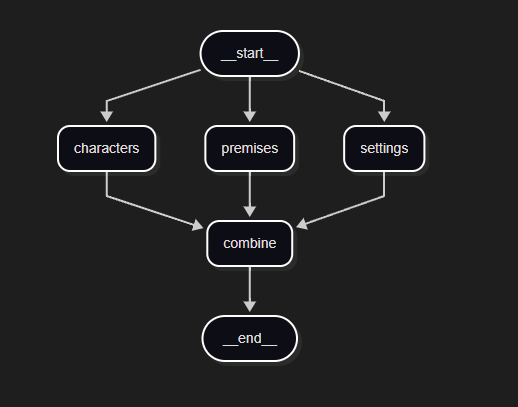

In [7]:
# import your LLM model
from langchain_ollama import ChatOllama
llm = ChatOllama(model='llama3.1:8b')
results = llm.invoke('Hello my name is Hanif')
print(results)

content="Hello Hanif! It's nice to meet you. Is there something I can help you with or would you like to chat?" additional_kwargs={} response_metadata={'model': 'llama3.1:8b', 'created_at': '2025-10-25T07:43:07.9287306Z', 'done': True, 'done_reason': 'stop', 'total_duration': 1750754600, 'load_duration': 28065700, 'prompt_eval_count': 16, 'prompt_eval_duration': 212381700, 'eval_count': 27, 'eval_duration': 1509446900, 'model_name': 'llama3.1:8b'} id='run--300ea817-800e-4db3-abe7-a3f60e79b45c-0' usage_metadata={'input_tokens': 16, 'output_tokens': 27, 'total_tokens': 43}


In [8]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image,display,Markdown

class State(TypedDict):
    topic : str
    characters : str
    settings: str
    premises: str
    story_intro : str

In [9]:
def generate_characters(state:State):
    """ Generate characters based on description """
    msg = llm.invoke(f"Create two characters names and brief traits for story about {state['topic']}")
    return {"characters": msg.content}

def generate_settings(state:State):
    """Generate story settings"""
    msg = llm.invoke(f"Describe a vivid setting for story about {state['topic']}")
    return {"settings": msg.content}

def generate_premises(state:State):
    """Generate story premises"""
    msg = llm.invoke(f"Generate a one sentence plot premise for story about {state['topic']}")
    return {"premises": msg.content}

def combine_elements(state:State):
    """Combine characters, settings, and premises into a story intro"""
    msg = llm.invoke(
        f"Write a short story introduction using the following elements. "
        f"Using the characters: {state['characters']}, "
        f"settings: {state['settings']}, and "
        f"premises: {state['premises']}, "
        f"write a compelling story introduction."
    )
    return {"story_intro": msg.content}


In [10]:
graph = StateGraph(State)
graph.add_node("characters", generate_characters)
graph.add_node("settings", generate_settings)
graph.add_node("premises", generate_premises)
graph.add_node("combine", combine_elements)

graph.add_edge(START, "characters")
graph.add_edge(START, "settings")
graph.add_edge(START, "premises")
graph.add_edge("characters", "combine")
graph.add_edge("settings", "combine")
graph.add_edge("premises", "combine")
graph.add_edge("combine", END)

compiled_graph = graph.compile()
mermaid_code = compiled_graph.get_graph().draw_mermaid()
with open("prompt_chaining_graph.mmd", "w") as f:
    f.write(mermaid_code)

In [11]:
# Stream to monitoring graph execution
config = {'configurable': {'thread_id': '2'}}
state={"topic":"Good governance goverment"}
for chunk in compiled_graph.stream(state,config,stream_mode='updates'):
    print(chunk)

{'characters': {'characters': 'Here are two potential character profiles:\n\n**1. Character Name: Nalini Patel**\n\n* Age: 35\n* Occupation: Civil Society Activist\n* Personality: Nalini is a determined and compassionate individual who has dedicated her life to promoting good governance in her country. She is well-respected in the community for her knowledge of governance principles and her ability to bring people together to achieve common goals.\n* Traits: Nalini is a natural communicator, able to articulate complex ideas in simple terms. She is also an effective organizer, skilled at mobilizing volunteers and resources to support her initiatives.\n\n**2. Character Name: Rohan Mehta**\n\n* Age: 40\n* Occupation: Public Sector Official (Ministry of Finance)\n* Personality: Rohan is a seasoned bureaucrat with a passion for public service. He is committed to delivering high-quality services to the people, but often finds himself constrained by red tape and bureaucratic inefficiencies.\n

## Routing

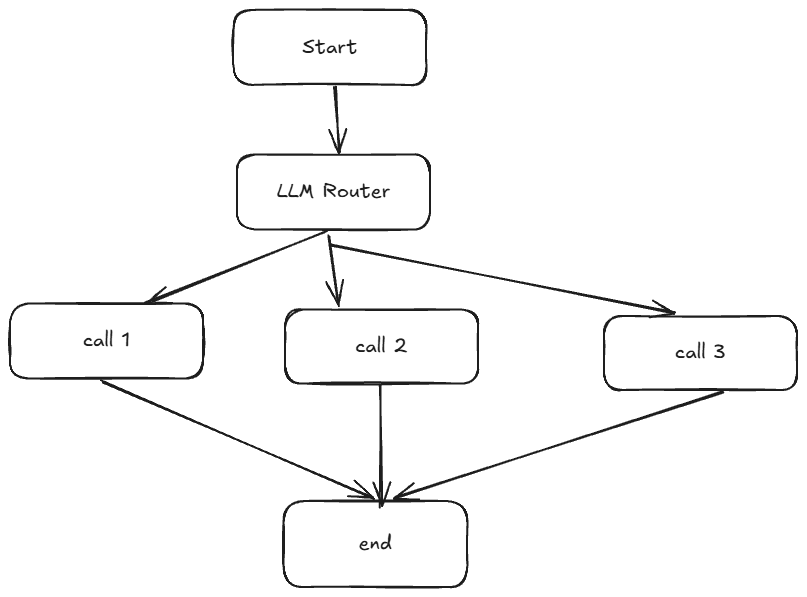

In [12]:
from typing_extensions import Literal
from pydantic import BaseModel,Field
from langchain_core.messages import HumanMessage,SystemMessage

# Schema for structured output as routing logic
class Route(BaseModel):
    step: Literal["poem","story","joke"]=Field(description="The next step in routing process")

# Augment theLLM with schema for structured output
router = llm.with_structured_output(Route)

## State(TypedDict)
class State(TypedDict):
    input:str
    decision:str
    output:str

def llm_call_1(state:State):
    """write a story"""
    result = llm.invoke(state['input'])
    return {"output":result.content}

def llm_call_2(state:State):
    """write a poem"""
    result = llm.invoke(state['input'])
    return {"output":result.content}

def llm_call_3(state:State):
    """write a joke"""
    result = llm.invoke(state['input'])
    return {"output":result.content}

def llm_call_router(state:State):
    """Route the input to the appropriate node"""
    decision = router.invoke(
        [
            SystemMessage(content="Route the input to story,joke or poem based onusers request"),
            HumanMessage(content = state["input"])
        ]
    )
    return{"decision":decision.step}

def route_decision(state:State):
    if state['decision'] == 'story':
        return 'llm_call_1'
    elif state['decision'] == 'poem':
        return 'llm_call_2'
    elif state['decision'] == 'joke':
        return 'llm_call_3'

In [13]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image,display

router_builder = StateGraph(State)
router_builder.add_node("llm_call_1",llm_call_1)
router_builder.add_node("llm_call_2",llm_call_2)
router_builder.add_node("llm_call_3",llm_call_3)
router_builder.add_node("llm_call_router",llm_call_router)

router_builder.add_edge(START,"llm_call_router")
router_builder.add_conditional_edges(
    "llm_call_router",
    route_decision,
    {
        "llm_call_1":"llm_call_1",
        "llm_call_2":"llm_call_2",
        "llm_call_3":"llm_call_3"
    }
)
router_builder.add_edge("llm_call_1",END)
router_builder.add_edge("llm_call_2",END)
router_builder.add_edge("llm_call_3",END)

router_workflow = router_builder.compile()


In [14]:
mermaid_code = router_workflow.get_graph().draw_mermaid()
with open("router_workflow.mmd", "w") as f:
    f.write(mermaid_code)

In [ ]:
result = router_workflow.invoke({"input":"Write me a joke about Data Engineer"})

{'input': 'Write me a joke about Data Engineer', 'decision': 'joke', 'output': "Here's one:\n\nWhy did the data engineer quit his job?\n\nBecause he couldn't work with all the data-bility issues! (get it? reliability... haha)"}


In [16]:
# Stream to monitoring graph execution
config = {'configurable': {'thread_id': '3'}}
state={"input":"Give me a story about Government"}
for chunk in router_workflow.stream(state,config,stream_mode='updates'):
    print(chunk)

{'llm_call_router': {'decision': 'story'}}
{'llm_call_1': {'output': 'Here\'s a story about the government, exploring themes of power, responsibility, and the complexities of bureaucracy.\n\n**The Island of Azura**\n\nOn a small island nation called Azura, nestled in the heart of the Pacific, a unique experiment was underway. The country had long been governed by a council of wise elders who made decisions for the benefit of all citizens. But as Azura began to grow and prosper, its leaders realized that they needed a more structured system to manage the island\'s affairs.\n\nA new constitution was drafted, creating a democratic government with three branches: Executive, Legislative, and Judicial. The people of Azura were enthusiastic about their newfound freedom, but also wary of the potential for corruption and abuse of power.\n\nOne day, a young man named Kai was chosen to be the first Prime Minister of Azura. He was ambitious, intelligent, and well-liked by his peers. But as he bega

## Orchestration - Worker

Breakdown the task and delegate worker LLMs and synthenesizes their results

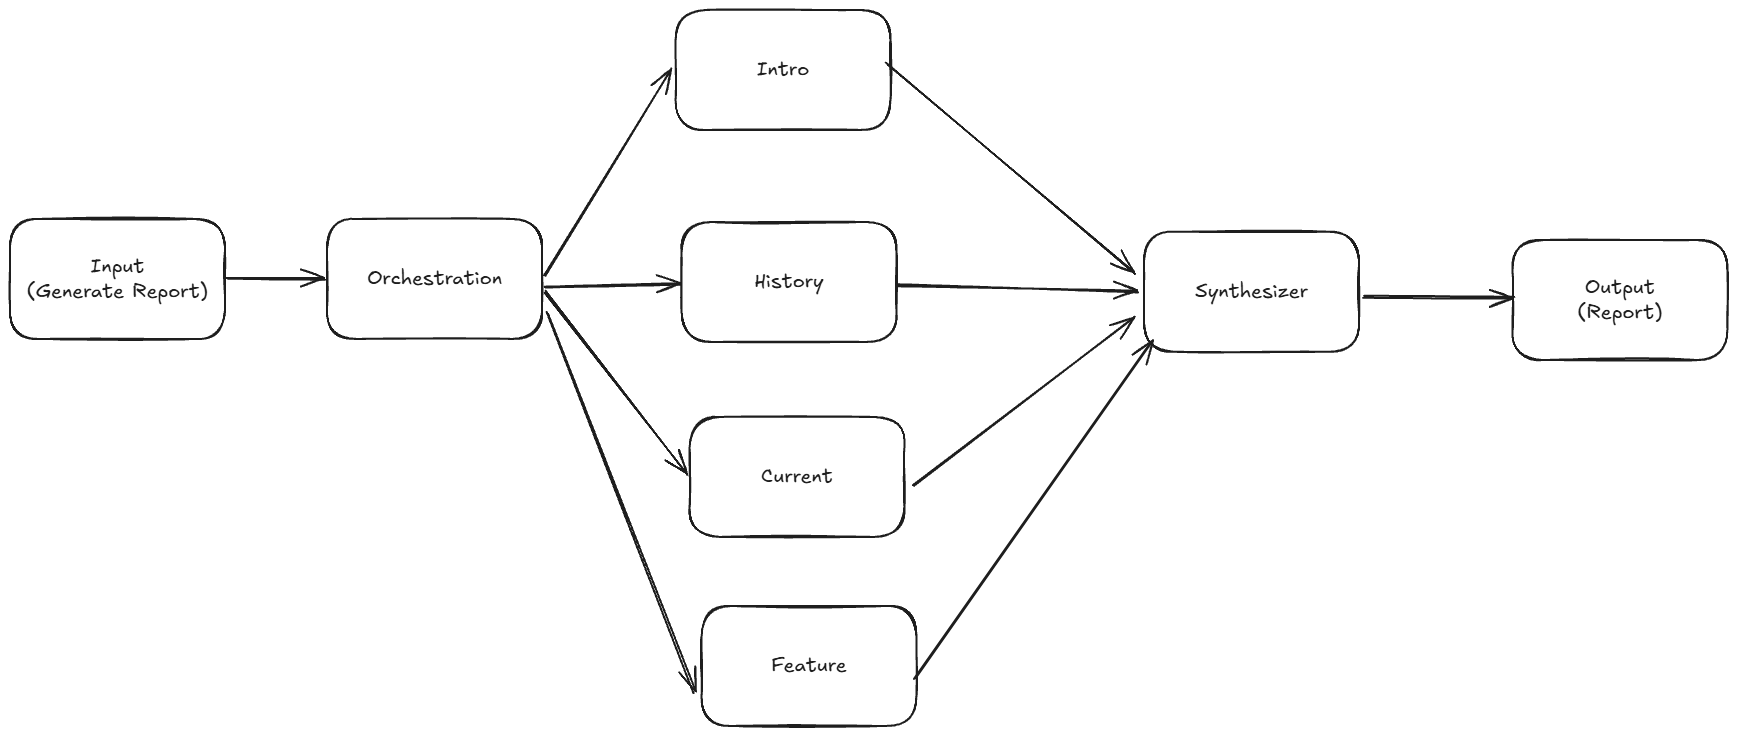

In [17]:
# import your LLM model
from langchain_ollama import ChatOllama
llm = ChatOllama(model='llama3.1:8b')

In [22]:
from typing import Annotated, List
import operator
from pydantic import BaseModel,Field
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image,display,Markdown
from langchain_core.runnables.graph import MermaidDrawMethod

In [24]:
class Section(BaseModel):
    name : str = Field (description= "Name for this section of the report")
    description : str = Field( description = 'Brief overview of the main topics and concepts of the section')

class Sections(BaseModel):
    sections:List[Section] = Field(
        description= "Sections of the report"
    )
planner = llm.with_structured_output(Sections)

### Create workers dynamically in LangGraph

Because orchestrator-worker workflow is common, LangGraph has the send API to support this

In [ ]:
from langgraph.constants import Send

class State(TypedDict):
    topic : str
    sections : list[Section]
    completed_sections : Annotated[
        list, operator.add
    ]
    final_report : str

class WorkerState(TypedDict):
    topic : str
    section : Section
    section_content : str
